<a href="https://colab.research.google.com/github/MantaHonk/EOS_Weather_Data_Analysis/blob/main/Term_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h3><b>EOS 230 Term Project</b><h3>
<h1>Predicting YYJ International Airport's Daily Mean Temperature From Victoria, BC</h1>
<h4>Authored by Logan Saunderson<br><br><hr>

# Introduction


<h2>Background</h2>
We are asked by a local company to determine if using another station is feasible in the case of a critical error or emergency in relation to weather data. Particularily, this company is in charge of managing incoming and outgoing aircrafts in airports. In the event that the weather station is unexpectedly shut off, we need to be able to generate weather data to determine if aircrafts can fly in and out of the airport safely. They gave us the research question: <b>Can we use Victoria Gonzales Station's Current Data to Estimate YYJ International Airport Station's Unknown Daily Mean Temperature?</b>

<h2>Stations</h2>
Two stations were used, both located in the Capital Region District (Greater Victoria) of British Columbia (Fig. 1). As seen on the figure, YYJ International Airport is located southwest of Sidney. Victoria Gonzales Station is located just south of Oak Bay (labeled, just low quality).
YYJ's weather station has data collected from 1940-2013 and Victoria Gonzales is from 1973-2026. We will investigate the dataframes to determine the scale of our study and potential break points.

<h2>Objective</h2>
Our goal with this study is to determine whether data from Victoria Gonzales Weather Station could be used to predict the temperature of YYJ International Airport after its station's lifespan to simulate a longlasting outage of weather data from this location. We will determine the feasibility of using this station to predict the missing years of data for YYJ International Airport's station using statistical analysis.

Figure 1: Map of Greater Victoria

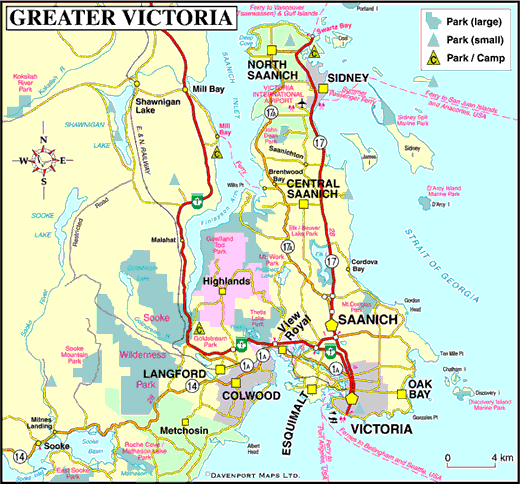

#Data ingest and EDA

We will now bring in the datasets from the weather stations and import Python libraries that we will use for our exploratory data analysis.

1. Data Collection

Our data is stored within my personal GitHub, where the datafiles were sourced from the assignment station picker Jupyter Notebook. We will also install all of the libraries that we will need for our analysis and visualizations.

In [1]:
!git clone https://github.com/MantaHonk/EOS_Weather_Data_Analysis/

fatal: destination path 'EOS_Weather_Data_Analysis' already exists and is not an empty directory.


In [2]:
!pip install -q cartopy

In [3]:
#Libraries
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.shapereader import Reader
import numpy as np
from scipy.stats import norm
from sklearn.linear_model import LinearRegression

In [4]:
folder_path = "/content/EOS_Weather_Data_Analysis"
df_a_stn_id = '1018620'
df_b_stn_id = '1018611'

#VG stands for Victoria Gonzales
df_YYJ = pd.read_parquet(f"{folder_path}/eccc_{df_a_stn_id}_daily.parquet")
df_VG = pd.read_parquet(f"{folder_path}/eccc_{df_b_stn_id}_daily.parquet")

2. Data Cleaning

We want to check if there is any missing data, or any issues with the period of time we will use for our analysis. We know that the last year of the YYJ Airport dataframe is 2013, this doesn't mean that it ends on the last day of the year.

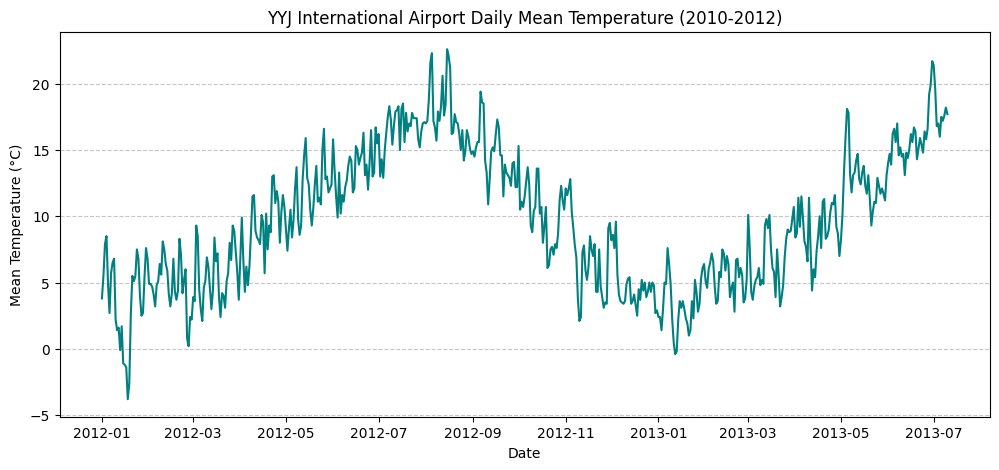

In [5]:
df_yyj_plot = df_YYJ[(df_YYJ['year'] >= 2012) & (df_YYJ['year'] <= 2013)]

plt.figure(figsize=(12, 5))
plt.plot(df_yyj_plot['timestamp'], df_yyj_plot['d_mean_temp'], color='teal')

plt.title("YYJ International Airport Daily Mean Temperature (2010-2012)")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



After checking the right end point of the YYJ data, we notice that the extent of 2013 is shortened to July 10th. Since the year is not complete, we will not consider 2013 for our analysis and use 2012 as our last year of interest.

As our goal is to predict future daily mean temperatures, we must consider a reasonable period of time to measure and collect data. We will use 3 complete years to make an accurate prediction while keeping resource use low and visualizations stable. We must now check for extreme values, anomalies, and missing data within the 2010-2012 extent for both datasets.



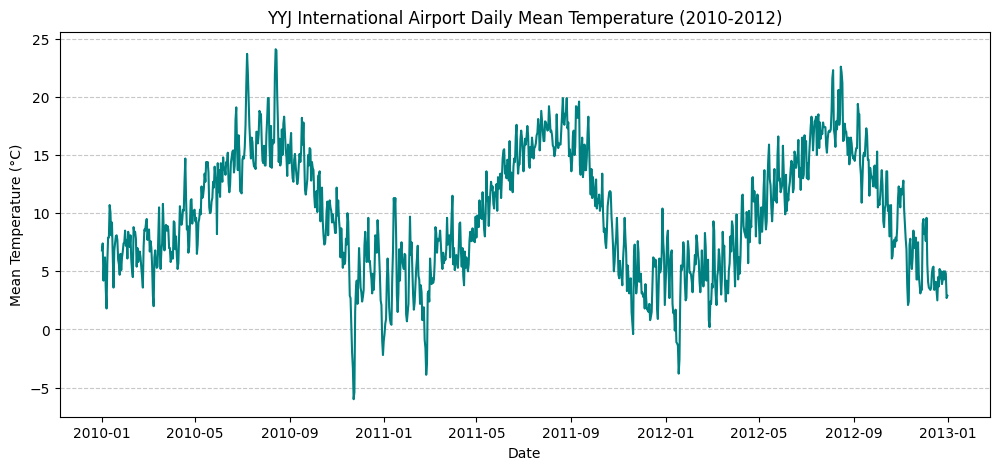

In [6]:
df_yyj_plot = df_YYJ[(df_YYJ['year'] >= 2010) & (df_YYJ['year'] <= 2012)]

plt.figure(figsize=(12, 5))
plt.plot(df_yyj_plot['timestamp'], df_yyj_plot['d_mean_temp'], color='teal')

plt.title("YYJ International Airport Daily Mean Temperature (2010-2012)")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



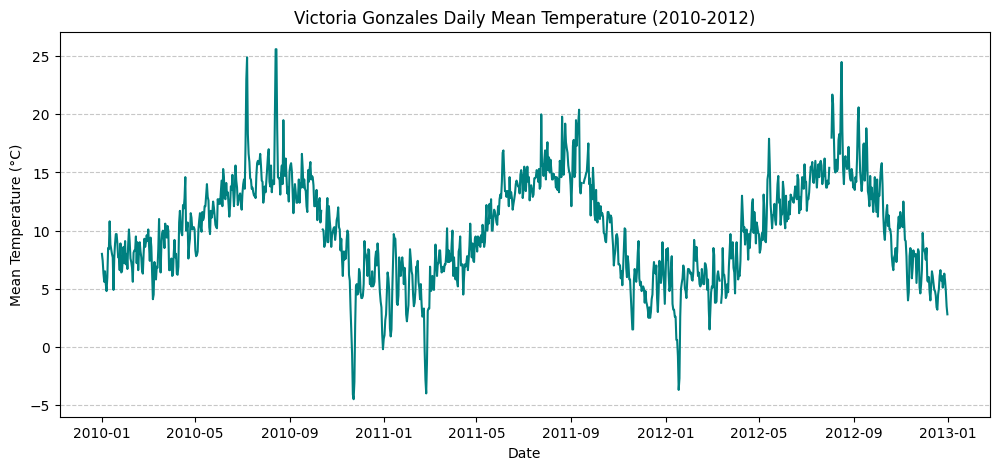

In [7]:
df_vg_plot = df_VG[(df_VG['year'] >= 2010) & (df_VG['year'] <= 2012)]

plt.figure(figsize=(12, 5))
plt.plot(df_vg_plot['timestamp'], df_vg_plot['d_mean_temp'], color='teal')

plt.title("Victoria Gonzales Daily Mean Temperature (2010-2012)")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [8]:
df_YYJ[(df_YYJ['year'] >=2010) & (df_YYJ['year'] <= 2012)].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 25568 to 26663
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   lon               1096 non-null   float64       
 1   lat               1096 non-null   float64       
 2   station_name      1096 non-null   object        
 3   timestamp         1096 non-null   datetime64[ns]
 4   year              1096 non-null   int64         
 5   d_max_temp        1096 non-null   float64       
 6   d_min_temp        1096 non-null   float64       
 7   d_mean_temp       1096 non-null   float64       
 8   total_rain        1096 non-null   float64       
 9   total_snow        1096 non-null   float64       
 10  total_precip      1096 non-null   float64       
 11  snow_on_ground    1096 non-null   float64       
 12  source_year_file  1096 non-null   int64         
dtypes: datetime64[ns](1), float64(9), int64(2), object(1)
memory usage: 119.9+ KB


In [9]:
df_VG[(df_VG['year'] >=2010) & (df_VG['year'] <= 2012)].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 13514 to 14609
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   lon               1096 non-null   float64       
 1   lat               1096 non-null   float64       
 2   station_name      1096 non-null   object        
 3   timestamp         1096 non-null   datetime64[ns]
 4   year              1096 non-null   int64         
 5   d_max_temp        1090 non-null   float64       
 6   d_min_temp        1095 non-null   float64       
 7   d_mean_temp       1090 non-null   float64       
 8   total_rain        0 non-null      float64       
 9   total_snow        0 non-null      float64       
 10  total_precip      1081 non-null   float64       
 11  snow_on_ground    0 non-null      float64       
 12  source_year_file  1096 non-null   int64         
dtypes: datetime64[ns](1), float64(9), int64(2), object(1)
memory usage: 119.9+ KB


By the .info() method, we determine that there are no missing values within the YYJ dataframe, but there are 6 missing data points for the daily mean temperature of the Victoria Gonzales dataframe.
Our procedure for fixing this is to take the mean of the first left and right non-null entries and insert the values manually.

In [10]:
df_VG['d_mean_temp'] = df_VG['d_mean_temp'].interpolate(method='linear', limit_direction='both')

df_VG.loc[df_VG.index, 'd_mean_temp'] = df_VG['d_mean_temp']

df_VG[(df_VG['year'] >=2010) & (df_VG['year'] <= 2012)].info()


<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 13514 to 14609
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   lon               1096 non-null   float64       
 1   lat               1096 non-null   float64       
 2   station_name      1096 non-null   object        
 3   timestamp         1096 non-null   datetime64[ns]
 4   year              1096 non-null   int64         
 5   d_max_temp        1090 non-null   float64       
 6   d_min_temp        1095 non-null   float64       
 7   d_mean_temp       1096 non-null   float64       
 8   total_rain        0 non-null      float64       
 9   total_snow        0 non-null      float64       
 10  total_precip      1081 non-null   float64       
 11  snow_on_ground    0 non-null      float64       
 12  source_year_file  1096 non-null   int64         
dtypes: datetime64[ns](1), float64(9), int64(2), object(1)
memory usage: 119.9+ KB


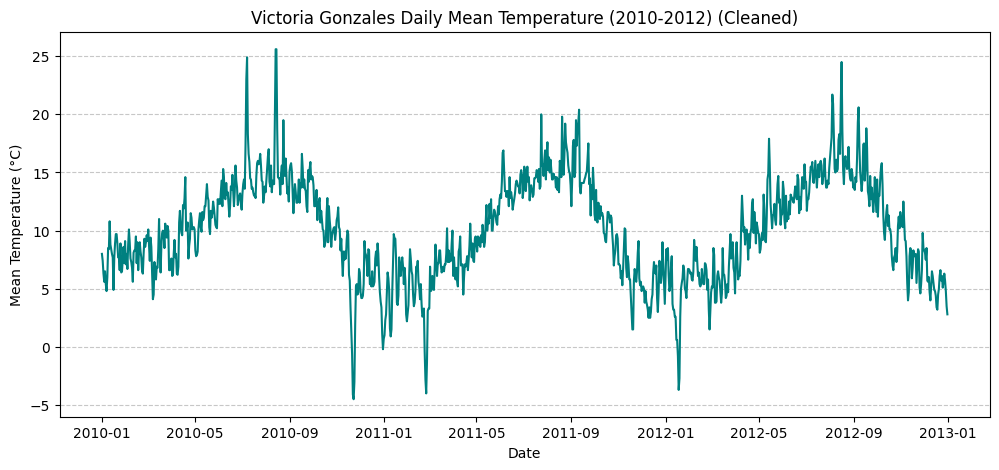

In [11]:
df_vg_plot_clean = df_VG[(df_VG['year'] >= 2010) & (df_VG['year'] <= 2012)]

plt.figure(figsize=(12, 5))
plt.plot(df_vg_plot_clean['timestamp'], df_vg_plot_clean['d_mean_temp'], color='teal')

plt.title("Victoria Gonzales Daily Mean Temperature (2010-2012) (Cleaned)")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

After looking at the graph and checking the Non-Null Count with the .info method, we can confirm that there is no longer missing data points within the VG dataframe.

In [12]:
df_VG.dtypes

,0
lon,float64
lat,float64
station_name,object
timestamp,datetime64[ns]
year,int64
d_max_temp,float64
d_min_temp,float64
d_mean_temp,float64
total_rain,float64
total_snow,float64


With the .dtypes method, we notice that we are given a datetime column, allowig us to continue with it and not form our own column for utilzation.

3. Summary Statistics

We will use a side-by-side boxplot to determine how similar the two stations are, by analyzing outliers and quantiles of the stations.

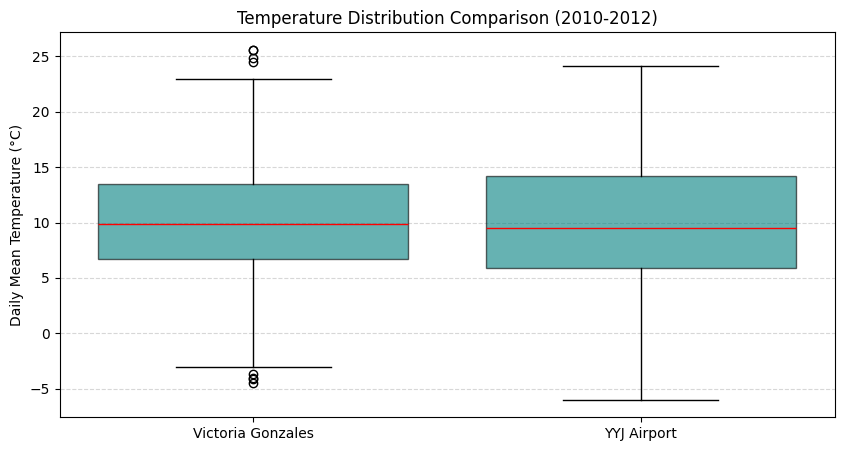

In [13]:
mask_yyj = (df_YYJ['year'] >= 2010) & (df_YYJ['year'] <= 2012)
mask_vg = (df_VG['year'] >= 2010) & (df_VG['year'] <= 2012)
df_yyj_t = df_YYJ.loc[mask_yyj, ['timestamp', 'd_mean_temp']].rename(columns={'d_mean_temp': 'temp_yyj'})
df_vg_t = df_VG.loc[mask_vg, ['timestamp', 'd_mean_temp']].rename(columns={'d_mean_temp': 'temp_gonzales'})
df_overlap = pd.merge(df_yyj_t, df_vg_t, on='timestamp')

def get_season(month):
    if month in [6, 7, 8]:
        return 'Summer'
    elif month in [12, 1, 2]:
        return 'Winter'
    else:
        return 'Other'

df_overlap['season'] = df_overlap['timestamp'].dt.month.apply(get_season)


plt.figure(figsize=(10, 5))
plt.boxplot([df_overlap['temp_gonzales'], df_overlap['temp_yyj']],
            tick_labels=['Victoria Gonzales', 'YYJ Airport'],
            patch_artist=True, # Allows us to fill with color
            boxprops=dict(facecolor='teal', color='black', alpha=0.6),
            medianprops=dict(color='red'), widths = .8)

plt.title("Temperature Distribution Comparison (2010-2012)")
plt.ylabel("Daily Mean Temperature (°C)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

By looking at the boxplots, we notice that the stations are similar, but Victoria Gonzales faces more extreme temperatures and variations. We notice that the daily mean temperature is approximately 0.5 degrees cooler at YYJ, and there are no outliers during the timeframe either. However, we do notice that Victoria Gonzales has outliers on both tails. We also notice that Victoria Gonzales has a smaller IQR, meaning that there is a larger clustering of data within this range. For the most part, the boxplots follow the same spread, but Victoria Gonzales experiences more variability and has more density. Using this station to approximate YYJ International's data would show general trends, but may form some error due to these observations.

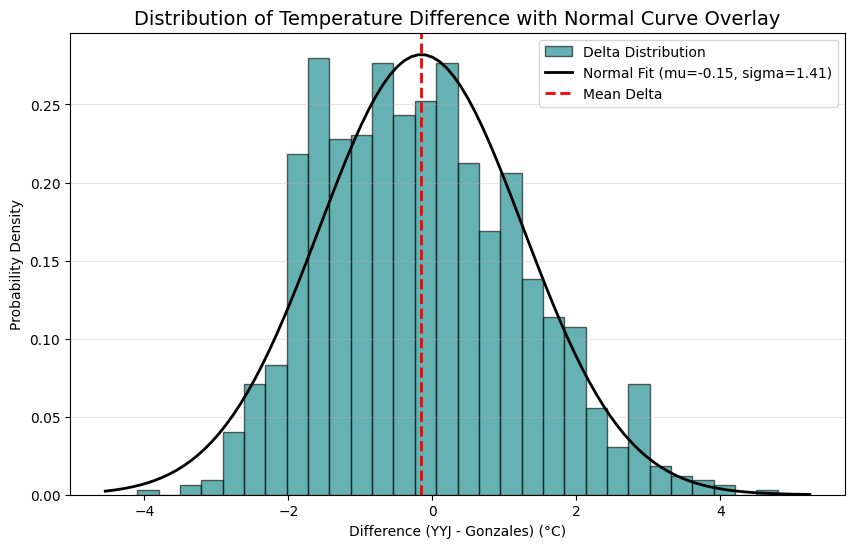

In [14]:
df_overlap['delta'] = df_overlap['temp_yyj'] - df_overlap['temp_gonzales']
mu, std = norm.fit(df_overlap['delta'])

plt.figure(figsize=(10, 6))

plt.hist(df_overlap['delta'], bins=30, density=True, color='teal', edgecolor='black', alpha=0.6, label='Delta Distribution')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Normal Fit (mu={mu:.2f}, sigma={std:.2f})')

plt.axvline(mu, color='red', linestyle='dashed', linewidth=2, label='Mean Delta')
plt.title("Distribution of Temperature Difference with Normal Curve Overlay", fontsize=14)
plt.xlabel("Difference (YYJ - Gonzales) (°C)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

We will take the differences between the daily temperature of the two stations to determine if the errors are normal. Looking at the outputted pdf, we notice that the stations mostly fit under the normal curve. This suggests that the values are predictable, and expected. The mean is slightly shifted towards the negative side, showing that the temperature at YYJ is on average less than that of Victoria Gonzales.

4. Data Visualization

We will show the stations in proximity to towns and cities in the region. Our goal is to determine if there are any significant geographical features that could be affecting the temperatures recorded at the stations.

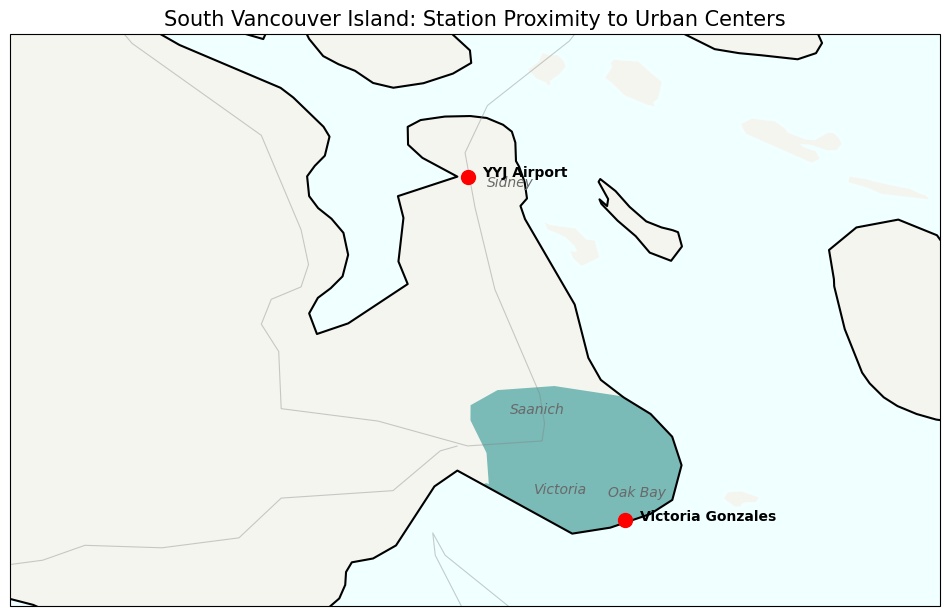

In [15]:
yyj_coords = (df_YYJ['lat'].iloc[0], df_YYJ['lon'].iloc[0])
vg_coords = (df_VG['lat'].iloc[0], df_VG['lon'].iloc[0])

plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-123.75, -123.1, 48.35, 48.75], crs=ccrs.PlateCarree())

urban_areas = cfeature.NaturalEarthFeature(
    category='cultural',
    name='urban_areas',
    scale='10m',
    facecolor='teal',
    edgecolor='none'
)
ax.add_feature(urban_areas, alpha=0.5, zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1.5)
ax.add_feature(cfeature.OCEAN.with_scale('10m'), facecolor='azure')
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='#f5f5f0')

roads = cfeature.NaturalEarthFeature(category='cultural', name='roads',
                                    scale='10m', facecolor='none',
                                    edgecolor='gray', linewidth=0.8)
ax.add_feature(roads, alpha=0.4)


towns = {
    "Victoria": (48.4284, -123.3656),
    "Sidney": (48.6430, -123.4000),
    "Saanich": (48.4843, -123.3814),
    "Oak Bay": (48.4264, -123.3117)
}

for town, coords in towns.items():
    ax.text(coords[1], coords[0], town, transform=ccrs.PlateCarree(),
            fontsize=10, color='dimgray', fontstyle='italic', ha='center')

ax.plot(yyj_coords[1], yyj_coords[0], 'ro', markersize=10, transform=ccrs.PlateCarree(), label="YYJ Airport")
ax.text(yyj_coords[1]+0.01, yyj_coords[0], "YYJ Airport", transform=ccrs.PlateCarree(), fontweight='bold')

ax.plot(vg_coords[1], vg_coords[0], 'ro', markersize=10, transform=ccrs.PlateCarree(), label="Gonzales Stn")
ax.text(vg_coords[1]+0.01, vg_coords[0], "Victoria Gonzales", transform=ccrs.PlateCarree(), fontweight='bold')

plt.title("South Vancouver Island: Station Proximity to Urban Centers", fontsize=15)
plt.show()

From the cartographic visualization, we notice the proximity of the two stations, with the distance between the two being roughly 25 kms. We notice that both locations are close to the ocean, but Victoria Gonzales is more direct, whereas the airport is more inland.

Note: for more detail of the Capital Region District, see Figure 1 above.

5. Correlation Analysis

We want to ensure that Victoria Gonzales will be an adequate station to use as a reference for our additional data we want to estimate. We will use a scatterplot and plot daily mean temperatures for both of the data sets. From this, we will find the R^2 value and determine if there is any correlation between the two stations.

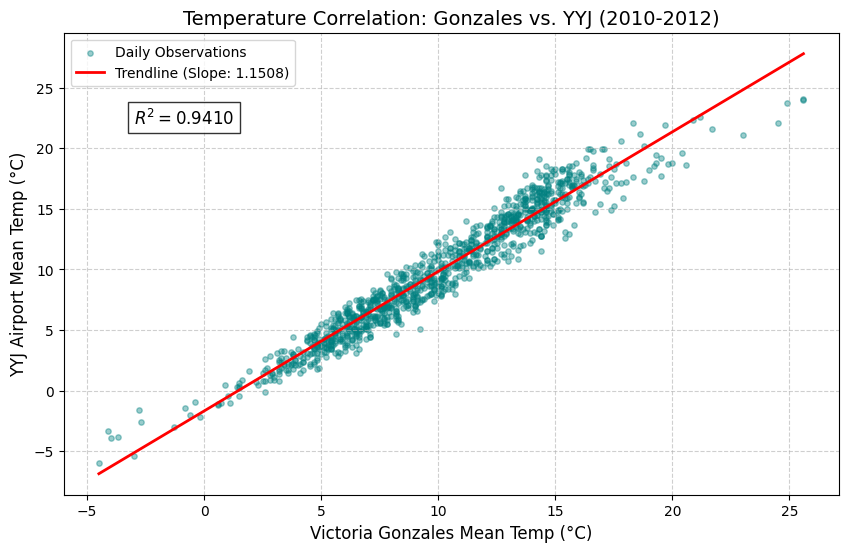

In [16]:
z = np.polyfit(df_overlap['temp_gonzales'], df_overlap['temp_yyj'], 1)
p = np.poly1d(z)


plt.figure(figsize=(10, 6))


plt.scatter(df_overlap['temp_gonzales'], df_overlap['temp_yyj'],
            alpha=0.4, s=15, color='teal', label='Daily Observations')


x_range = np.linspace(df_overlap['temp_gonzales'].min(), df_overlap['temp_gonzales'].max(), 100)
plt.plot(x_range, p(x_range), color='red', linewidth=2, label=f'Trendline (Slope: {z[0]:.4f})')


plt.title("Temperature Correlation: Gonzales vs. YYJ (2010-2012)", fontsize=14)
plt.xlabel("Victoria Gonzales Mean Temp (°C)", fontsize=12)
plt.ylabel("YYJ Airport Mean Temp (°C)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.text(-3, 22, f'$R^2 = 0.9410$', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.show()

From the plot, we see that there is a high correlation, suggesting a strong fit. We will now test to see if there is any additional information we are missing, particularily in seasonal changes. We will break the scatterplot into summer and winter and test their individual correlations.



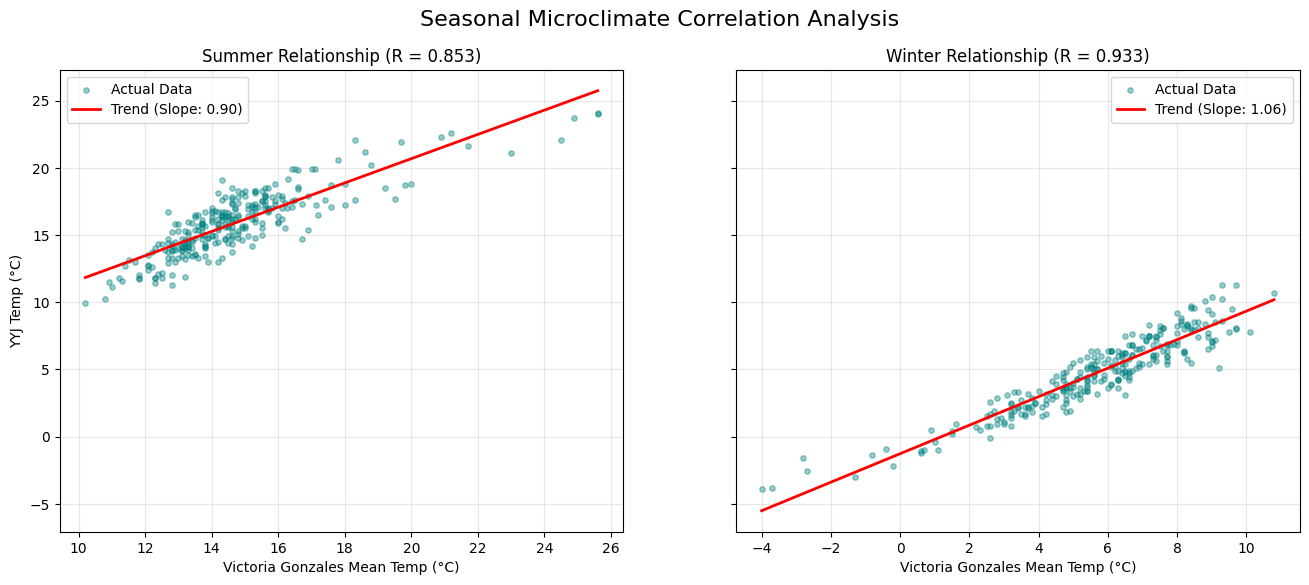

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, season in zip([ax1, ax2], ['Summer', 'Winter']):

    data = df_overlap[df_overlap['season'] == season]


    ax.scatter(data['temp_gonzales'], data['temp_yyj'],
            alpha=0.4, color='teal', s=15, label='Actual Data')

    slope, intercept = np.polyfit(data['temp_gonzales'], data['temp_yyj'], 1)
    line_fn = np.poly1d([slope, intercept])

    x_range = np.linspace(data['temp_gonzales'].min(), data['temp_gonzales'].max(), 100)
    ax.plot(x_range, line_fn(x_range), color='red', linewidth=2, label=f'Trend (Slope: {slope:.2f})')

    corr = data['temp_gonzales'].corr(data['temp_yyj'])

    ax.set_title(f"{season} Relationship (R = {corr:.3f})")
    ax.set_xlabel("Victoria Gonzales Mean Temp (°C)")
    if ax == ax1: ax.set_ylabel("YYJ Temp (°C)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Seasonal Microclimate Correlation Analysis", fontsize=16)
plt.show()

We notice that there was in fact some seasonal trends we missed during our first correlation analysis. The winter relationship is stronger than the summer, with a larger spread of data along the trendline. The summer data appears to have a stronger clustering, but more outliers especially on the warmer end of the scale. This shows that Victoria Gonzales is more prone to extreme warm temperatures than YYJ Airport.



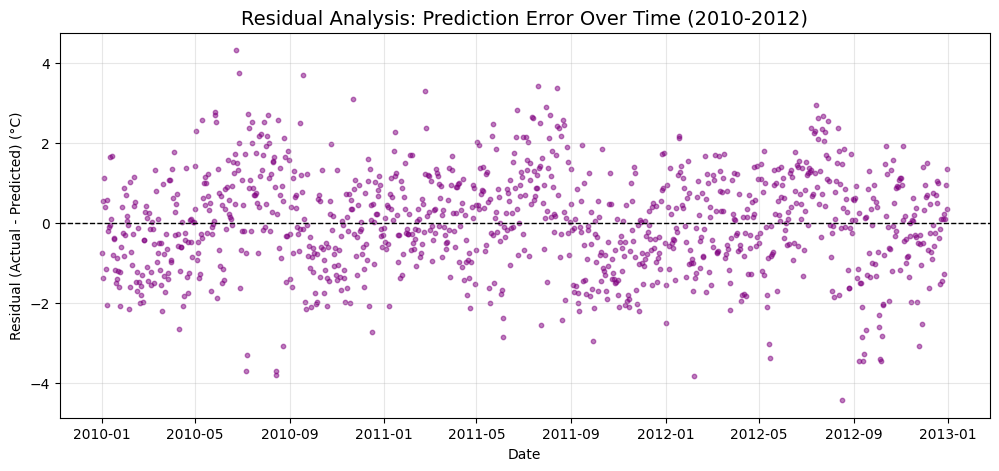

In [18]:
df_overlap['predicted_yyj'] = z[0] * df_overlap['temp_gonzales'] + z[1]
df_overlap['residuals'] = df_overlap['temp_yyj'] - df_overlap['predicted_yyj']

plt.figure(figsize=(12, 5))
plt.scatter(df_overlap['timestamp'], df_overlap['residuals'], color='purple', alpha=0.5, s=10)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title("Residual Analysis: Prediction Error Over Time (2010-2012)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted) (°C)")
plt.grid(True, alpha=0.3)
plt.show()

The goal of the residual plot is to locate any underlying trends in the residual, or error of the linear model. A well fitted model would show a randomly scattered plot, meaning there are no discernibke trends. As we can see from the plot above, the data points are in fact random, showing that our linear model is a good fit and we can use it for our prediction of weather data for YYJ Airport.

# Regression / Prediction / Results

We will now model the linear regression for the estimated time frame, from 2013-2026 for the YYJ Internation Airport Station. We will proceed with multiple plots demonstrating strengths and weaknesses of the model we build. We need to first train the model with the relationship built above.

In [19]:
x = df_overlap[['temp_gonzales']].values
y = df_overlap['temp_yyj'].values

model = LinearRegression()
model.fit(x, y)

slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(x, y)

print(f"The Prediction Equation is: YYJ_Temp = ({slope:.4f} * Gonzales_Temp) + {intercept:.4f}")
print(f"Final Model R-Squared: {r_squared:.4f}")

df_future = df_VG[df_VG['year'] >= 2013].copy()
x_future = df_future[['d_mean_temp']].values
df_future['predicted_yyj'] = model.predict(x_future)
min_year = df_future['year'].min()
max_year = df_future['year'].max()

print(f"The regression model created data for {max_year - min_year + 1} years, from {min_year} to {max_year}.")
df_future[['timestamp', 'd_mean_temp', 'predicted_yyj']].head()


The Prediction Equation is: YYJ_Temp = (1.1508 * Gonzales_Temp) + -1.6667
Final Model R-Squared: 0.9410
The regression model created data for 14 years, from 2013 to 2026.


,timestamp,d_mean_temp,predicted_yyj
14610,2013-01-01,3.3,2.130886
14611,2013-01-02,4.5,3.511810
14612,2013-01-03,3.0,1.785656
14613,2013-01-04,4.7,3.741963
14614,2013-01-05,6.1,5.353040


Our model now contains data for the next 14 years, from 2013-2016 using the relation of data between the two stations from 2010-2012. Let's now plot the next two years of predicted data beside our recorded data.

At first glance, it appears that the data follows the seasonal change observed at YYJ Airport quite strongly. There does not appear to be any issues at the moment.

Now that we have a plot to view our predicted model, I must acknowledge that I have intentionally kept some data hidden from the readers. YYJ International Airport does in fact have data from 2013-2026, albeit in a different station. Now that we know this, we can compare our predicted weather to our observed weather and determine if the model was actually a good fit.

We will clean up this data before comparing it to the model.

In [20]:
df_c_stn_id = '1018621'
df_YYJ_new = pd.read_parquet(f"{folder_path}/eccc_{df_c_stn_id}_daily.parquet")

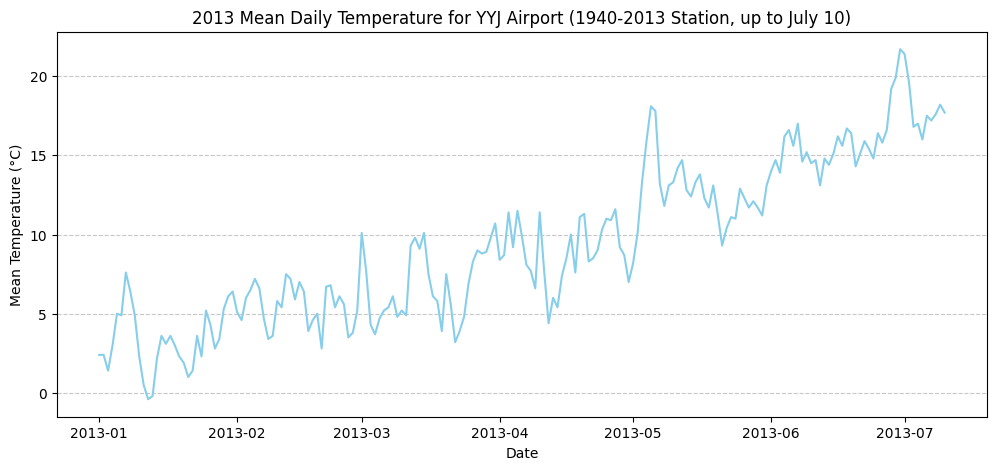

In [21]:
cutoff_date = pd.Timestamp('2013-07-10')
df_YYJ_2013_old_station_part = df_YYJ[(df_YYJ['year'] == 2013) & (df_YYJ['timestamp'] <= cutoff_date)].copy()

plt.figure(figsize=(12, 5))
plt.plot(df_YYJ_2013_old_station_part['timestamp'], df_YYJ_2013_old_station_part['d_mean_temp'], color='skyblue')
plt.title("2013 Mean Daily Temperature for YYJ Airport (1940-2013 Station, up to July 10)")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

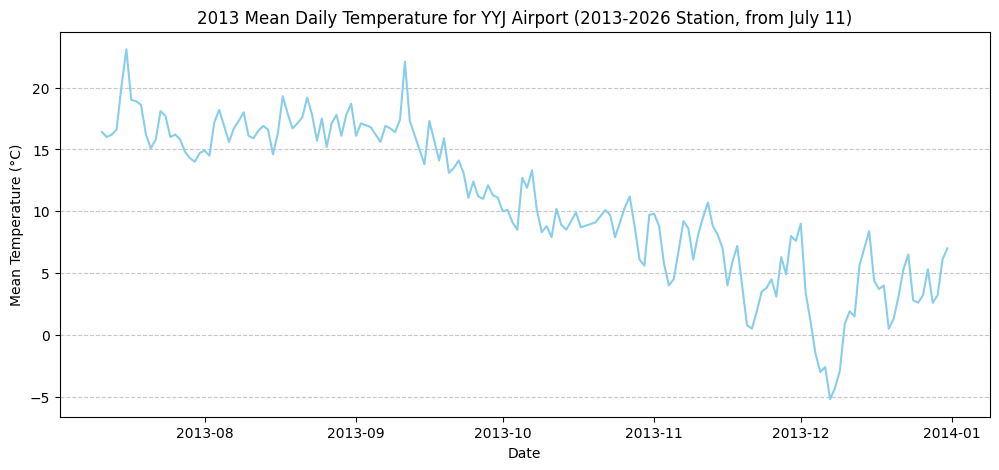

In [22]:
df_YYJ_new['d_mean_temp'] = df_YYJ_new['d_mean_temp'].interpolate(method='linear', limit_direction='forward')

df_YYJ_2013_new_station_part = df_YYJ_new[
    (df_YYJ_new['year'] == 2013) &
    (df_YYJ_new['timestamp'] > cutoff_date)
].copy()

plt.figure(figsize=(12, 5))
plt.plot(df_YYJ_2013_new_station_part['timestamp'], df_YYJ_2013_new_station_part['d_mean_temp'], color='skyblue')
plt.title("2013 Mean Daily Temperature for YYJ Airport (2013-2026 Station, from July 11)")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

We have both of the station's data for 2013, now we just need to combine them. We will put the input into our existing df_YYJ_new, to complete the year 2013.

In [23]:
df_YYJ_new_combined_2013 = pd.concat([df_YYJ_2013_old_station_part, df_YYJ_2013_new_station_part]).sort_values('timestamp').reset_index(drop=True)

df_YYJ_new_combined_2013['d_mean_temp'] = df_YYJ_new_combined_2013['d_mean_temp'].interpolate(method='linear', limit_direction='both')


df_YYJ_actual_full_2013_onwards = pd.concat([
    df_YYJ_new_combined_2013,
    df_YYJ_new[df_YYJ_new['year'] > 2013]
]).sort_values('timestamp').reset_index(drop=True)

df_YYJ_actual_full_2013_onwards['d_mean_temp'] = df_YYJ_actual_full_2013_onwards['d_mean_temp'].interpolate(method='linear', limit_direction='both')

print("Combined YYJ Actual Data (2013 onwards - head):")
display(df_YYJ_actual_full_2013_onwards.head())
print("\nCombined YYJ Actual Data (2013 onwards - tail):")
display(df_YYJ_actual_full_2013_onwards.tail())
df_YYJ_actual_full_2013_onwards.info()

Combined YYJ Actual Data (2013 onwards - head):


,lon,lat,station_name,timestamp,year,d_max_temp,d_min_temp,d_mean_temp,total_rain,total_snow,total_precip,snow_on_ground,source_year_file
0,-123.43,48.65,VICTORIA INT'L A,2013-01-01,2013,4.6,0.1,2.4,0.0,0.0,0.0,0.0,2013
1,-123.43,48.65,VICTORIA INT'L A,2013-01-02,2013,6.2,-1.5,2.4,0.0,0.0,0.0,0.0,2013
2,-123.43,48.65,VICTORIA INT'L A,2013-01-03,2013,5.5,-2.8,1.4,3.4,0.0,3.4,0.0,2013
3,-123.43,48.65,VICTORIA INT'L A,2013-01-04,2013,4.7,1.3,3.0,5.2,0.0,5.2,0.0,2013
4,-123.43,48.65,VICTORIA INT'L A,2013-01-05,2013,7.4,2.5,5.0,4.6,0.0,4.6,0.0,2013



Combined YYJ Actual Data (2013 onwards - tail):


,lon,lat,station_name,timestamp,year,d_max_temp,d_min_temp,d_mean_temp,total_rain,total_snow,total_precip,snow_on_ground,source_year_file
5108,-123.43,48.65,VICTORIA INTL A,2026-12-27,2026,NaN,NaN,3.4,NaN,NaN,NaN,NaN,2026
5109,-123.43,48.65,VICTORIA INTL A,2026-12-28,2026,NaN,NaN,3.4,NaN,NaN,NaN,NaN,2026
5110,-123.43,48.65,VICTORIA INTL A,2026-12-29,2026,NaN,NaN,3.4,NaN,NaN,NaN,NaN,2026
5111,-123.43,48.65,VICTORIA INTL A,2026-12-30,2026,NaN,NaN,3.4,NaN,NaN,NaN,NaN,2026
5112,-123.43,48.65,VICTORIA INTL A,2026-12-31,2026,NaN,NaN,3.4,NaN,NaN,NaN,NaN,2026


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5113 entries, 0 to 5112
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   lon               5113 non-null   float64       
 1   lat               5113 non-null   float64       
 2   station_name      5113 non-null   object        
 3   timestamp         5113 non-null   datetime64[ns]
 4   year              5113 non-null   int64         
 5   d_max_temp        4765 non-null   float64       
 6   d_min_temp        4762 non-null   float64       
 7   d_mean_temp       5113 non-null   float64       
 8   total_rain        4777 non-null   float64       
 9   total_snow        4801 non-null   float64       
 10  total_precip      4794 non-null   float64       
 11  snow_on_ground    344 non-null    float64       
 12  source_year_file  5113 non-null   int64         
dtypes: datetime64[ns](1), float64(9), int64(2), object(1)
memory usage: 519.4+ KB


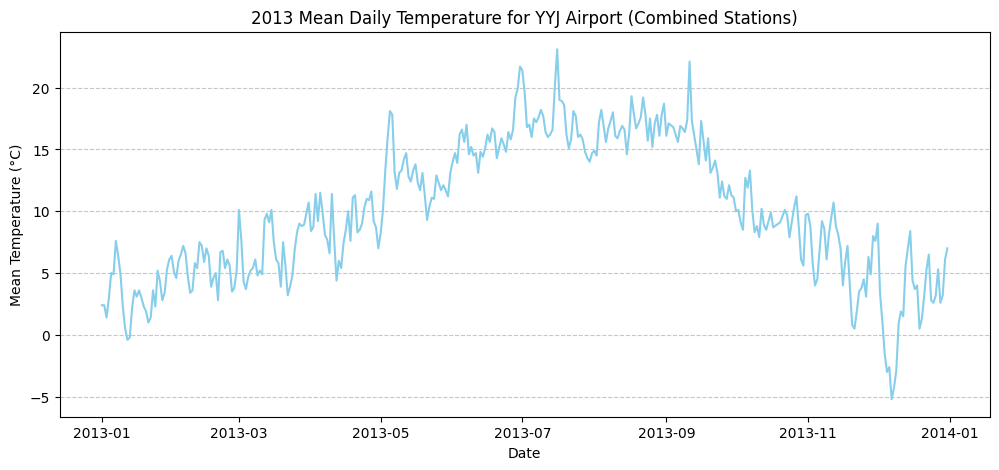

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(df_YYJ_new_combined_2013['timestamp'], df_YYJ_new_combined_2013['d_mean_temp'], color='skyblue')
plt.title("2013 Mean Daily Temperature for YYJ Airport (Combined Stations)")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

We now have a full calendar year of data for 2013. We will now begin comparing our model with this actual data.

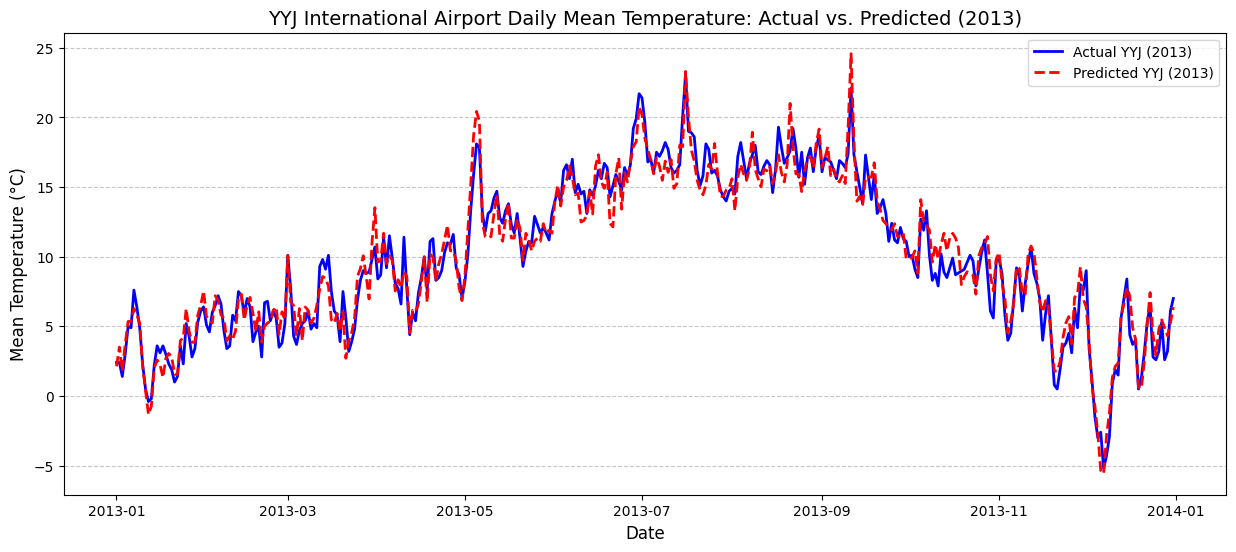

In [25]:
df_predicted_2013 = df_future[df_future['year'] == 2013][['timestamp', 'predicted_yyj']]

df_actual_2013 = df_YYJ_new_combined_2013[['timestamp', 'd_mean_temp']]

plt.figure(figsize=(15, 6))
plt.plot(df_actual_2013['timestamp'], df_actual_2013['d_mean_temp'], color='blue', linewidth=2, label='Actual YYJ (2013)')
plt.plot(df_predicted_2013['timestamp'], df_predicted_2013['predicted_yyj'], color='red', linestyle='--', linewidth=2, label='Predicted YYJ (2013)')

plt.title("YYJ International Airport Daily Mean Temperature: Actual vs. Predicted (2013)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Mean Temperature (°C)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Our time series shows that the model is a very good fit for estimating the actual data at YYJ Airport. Lets do some residual and scatterplot analysis to statistically show it.

In [26]:

df_model_comparison_2013 = pd.merge(df_actual_2013, df_predicted_2013, on='timestamp', suffixes=('_actual', '_predicted'))

df_model_comparison_2013 = df_model_comparison_2013.rename(columns={'d_mean_temp': 'temp_yyj_actual', 'predicted_yyj': 'temp_yyj_predicted'})

df_model_comparison_2013.dropna(subset=['temp_yyj_predicted', 'temp_yyj_actual'], inplace=True)

df_model_comparison_2013['season'] = df_model_comparison_2013['timestamp'].dt.month.apply(get_season)

print("Model Comparison DataFrame (first 5 rows):")
display(df_model_comparison_2013.head())

Model Comparison DataFrame (first 5 rows):


,timestamp,temp_yyj_actual,temp_yyj_predicted,season
0,2013-01-01,2.4,2.130886,Winter
1,2013-01-02,2.4,3.511810,Winter
2,2013-01-03,1.4,1.785656,Winter
3,2013-01-04,3.0,3.741963,Winter
4,2013-01-05,5.0,5.353040,Winter


In [27]:
df_YYJ_new[df_YYJ_new['year'] == 2013].info()

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 0 to 364
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   lon               365 non-null    float64       
 1   lat               365 non-null    float64       
 2   station_name      365 non-null    object        
 3   timestamp         365 non-null    datetime64[ns]
 4   year              365 non-null    int64         
 5   d_max_temp        167 non-null    float64       
 6   d_min_temp        167 non-null    float64       
 7   d_mean_temp       174 non-null    float64       
 8   total_rain        166 non-null    float64       
 9   total_snow        166 non-null    float64       
 10  total_precip      167 non-null    float64       
 11  snow_on_ground    3 non-null      float64       
 12  source_year_file  365 non-null    int64         
dtypes: datetime64[ns](1), float64(9), int64(2), object(1)
memory usage: 39.9+ KB


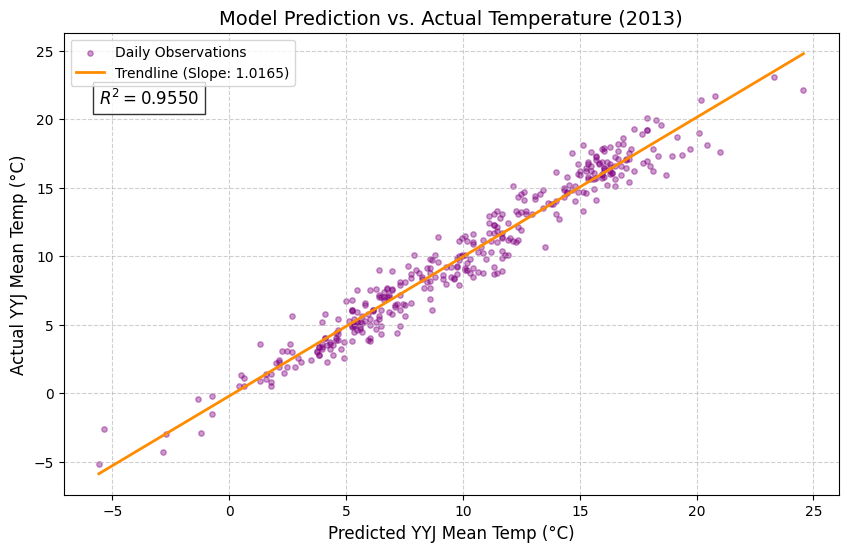

In [28]:
z_model = np.polyfit(df_model_comparison_2013['temp_yyj_predicted'], df_model_comparison_2013['temp_yyj_actual'], 1)
p_model = np.poly1d(z_model)

plt.figure(figsize=(10, 6))

plt.scatter(df_model_comparison_2013['temp_yyj_predicted'], df_model_comparison_2013['temp_yyj_actual'],
            alpha=0.4, s=15, color='purple', label='Daily Observations')

x_range_model = np.linspace(df_model_comparison_2013['temp_yyj_predicted'].min(), df_model_comparison_2013['temp_yyj_predicted'].max(), 100)
plt.plot(x_range_model, p_model(x_range_model), color='darkorange', linewidth=2, label=f'Trendline (Slope: {z_model[0]:.4f})')

r_squared_model = df_model_comparison_2013['temp_yyj_predicted'].corr(df_model_comparison_2013['temp_yyj_actual'])**2
plt.text(df_model_comparison_2013['temp_yyj_predicted'].min(), df_model_comparison_2013['temp_yyj_actual'].max() - 2,
         f'$R^2 = {r_squared_model:.4f}$', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.title("Model Prediction vs. Actual Temperature (2013)", fontsize=14)
plt.xlabel("Predicted YYJ Mean Temp (°C)", fontsize=12)
plt.ylabel("Actual YYJ Mean Temp (°C)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

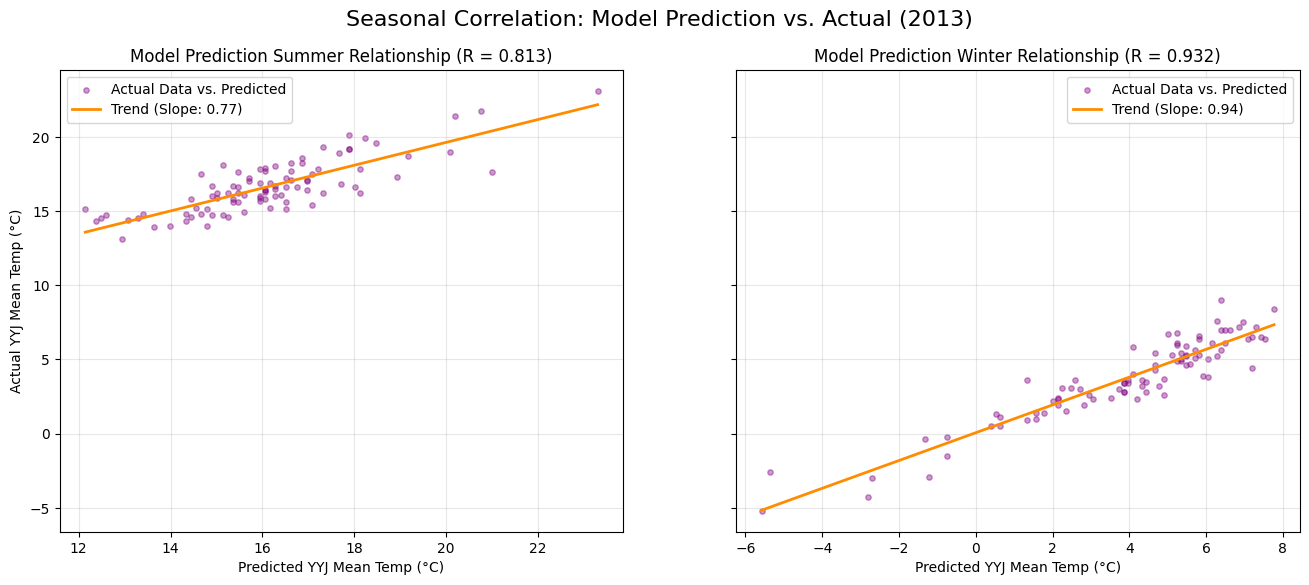

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, season in zip([ax1, ax2], ['Summer', 'Winter']):

    data_season = df_model_comparison_2013[df_model_comparison_2013['season'] == season]

    ax.scatter(data_season['temp_yyj_predicted'], data_season['temp_yyj_actual'],
               alpha=0.4, color='purple', s=15, label='Actual Data vs. Predicted')

    slope_season, intercept_season = np.polyfit(data_season['temp_yyj_predicted'], data_season['temp_yyj_actual'], 1)
    line_fn_season = np.poly1d([slope_season, intercept_season])

    x_range_season = np.linspace(data_season['temp_yyj_predicted'].min(), data_season['temp_yyj_predicted'].max(), 100)
    ax.plot(x_range_season, line_fn_season(x_range_season), color='darkorange', linewidth=2, label=f'Trend (Slope: {slope_season:.2f})')

    corr_season = data_season['temp_yyj_predicted'].corr(data_season['temp_yyj_actual'])

    ax.set_title(f"Model Prediction {season} Relationship (R = {corr_season:.3f})")
    ax.set_xlabel("Predicted YYJ Mean Temp (°C)")
    if ax == ax1: ax.set_ylabel("Actual YYJ Mean Temp (°C)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Seasonal Correlation: Model Prediction vs. Actual (2013)", fontsize=16)
plt.show()

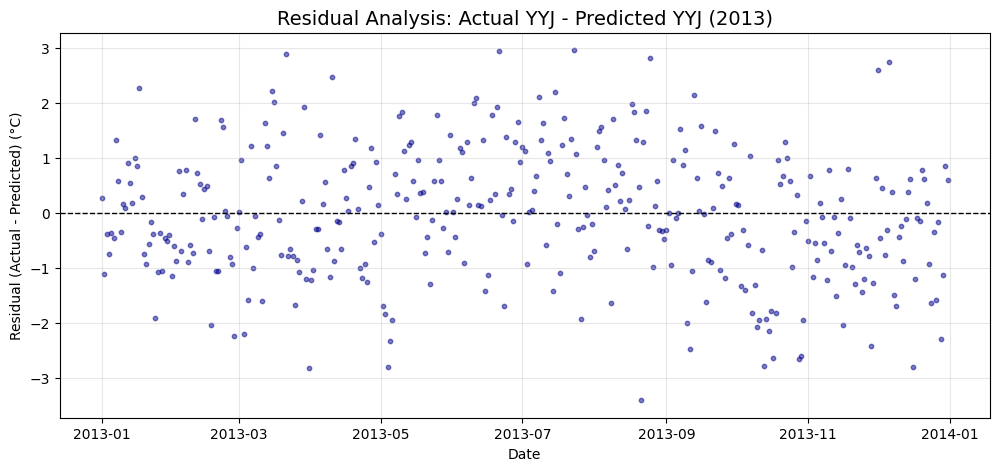

In [30]:
df_model_comparison_2013['residuals_model'] = df_model_comparison_2013['temp_yyj_actual'] - df_model_comparison_2013['temp_yyj_predicted']

plt.figure(figsize=(12, 5))
plt.scatter(df_model_comparison_2013['timestamp'], df_model_comparison_2013['residuals_model'], color='darkblue', alpha=0.5, s=10)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title("Residual Analysis: Actual YYJ - Predicted YYJ (2013)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted) (°C)")
plt.grid(True, alpha=0.3)
plt.show()